# Studying GPU utilization and power draw of Inception4 model taken from the MIT Supercloud dataset

This notebooks shows the exploratory data analysis of Inception4 jobs focusing on GPU utilization and energy efficiency

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shutil
import seaborn as sns

### Paths 

In [2]:
# This path points to the preprocessed data file after integrating system logs and 
# GPU logs and filtering unnecessary columns
DATA_PATH = '/project/scratch/p200631/Silvana/gpu_utilization/merged_gpu_node_resampled_final.csv'


### Baseline GPU Utilization & Efficiency Profiling

In [ ]:
# plot style
sns.set(style="whitegrid")

In [ ]:
df = pd.read_csv(DATA_PATH)

In [20]:
# --- 1. Summary Statistics ---
print("\n=== Summary Statistics ===")
print(df['utilization_gpu_pct'].describe())
print("\n=== Underutilized Samples (<30%) ===")
underutilized_pct = (df['utilization_gpu_pct'] < 30).mean() * 100
print(f"{underutilized_pct:.2f}% of samples have GPU utilization < 30%")


=== Summary Statistics ===
count    1.167961e+08
mean     9.357054e+01
std      1.481092e+01
min      0.000000e+00
25%      8.800000e+01
50%      1.000000e+02
75%      1.000000e+02
max      1.000000e+02
Name: utilization_gpu_pct, dtype: float64

=== Underutilized Samples (<30%) ===
1.87% of samples have GPU utilization < 30%


In [21]:
print("\n=== Overutilized Samples (>90%) ===")
overutilized_pct = (df['utilization_gpu_pct'] > 90).mean() * 100
print(f"{overutilized_pct:.2f}% of samples have GPU utilization > 90%")


=== Overutilized Samples (>90%) ===
71.95% of samples have GPU utilization > 90%


### Job-level aggregation

In [6]:
# Ensure timestamp is datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [7]:
# --- 1. Calculate Approx. Time Delta Between Samples ---
df = df.sort_values(['id_job', 'timestamp'])
df['time_delta_sec'] = df.groupby('id_job')['timestamp'].diff().dt.total_seconds()
df['time_delta_sec'].fillna(0, inplace=True)  # fill 0 for first row per job

In [8]:
# --- 2. Energy per Sample and Aggregation by Job ---
df['energy_sample_J'] = df['power_draw_W'] * df['time_delta_sec']

job_agg = df.groupby('id_job').agg(
    avg_utilization=('utilization_gpu_pct', 'mean'),
    max_utilization=('utilization_gpu_pct', 'max'),
    min_utilization=('utilization_gpu_pct', 'min'),
    avg_power_draw=('power_draw_W', 'mean'),
    total_energy_J=('energy_sample_J', 'sum'),
    avg_temperature=('temperature_gpu', 'mean'),
    avg_memory_used_MiB=('memory_used_MiB', 'mean'),
    actual_runtime_sec=('time_delta_sec', 'sum'),
    time_start=('time_start', 'first'),
    time_end=('time_end', 'first'),
    timelimit=('timelimit', 'first')
)

In [9]:
# Derived: actual job duration from SLURM timestamps
job_agg['job_duration_sec'] = job_agg['time_end'] - job_agg['time_start']
job_agg['job_duration_min'] = job_agg['job_duration_sec'] / 60
job_agg['timelimit_min'] = job_agg['timelimit'] / 60

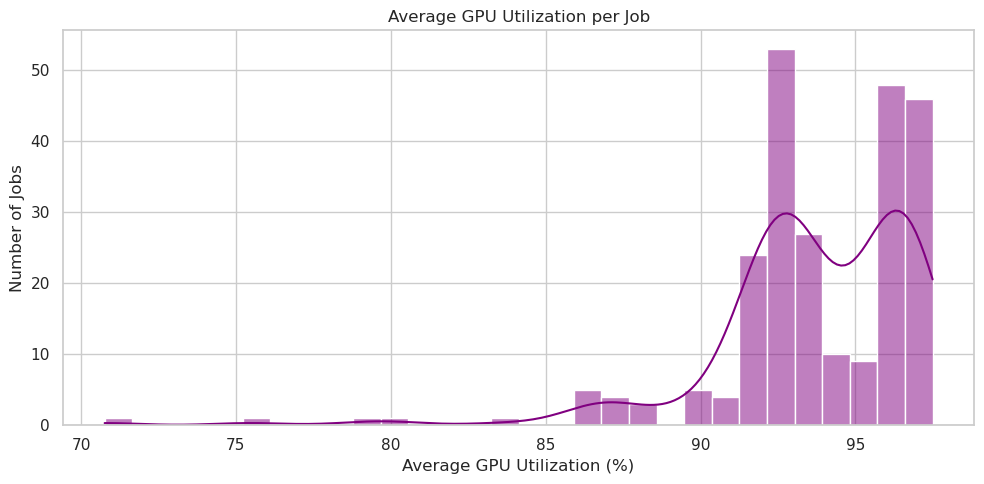

In [10]:
# --- 3. Histogram of Avg GPU Utilization by Job ---
plt.figure(figsize=(10, 5))
sns.histplot(job_agg['avg_utilization'], bins=30, kde=True, color='purple')
plt.title("Average GPU Utilization per Job")
plt.xlabel("Average GPU Utilization (%)")
plt.ylabel("Number of Jobs")
plt.tight_layout()
plt.show()

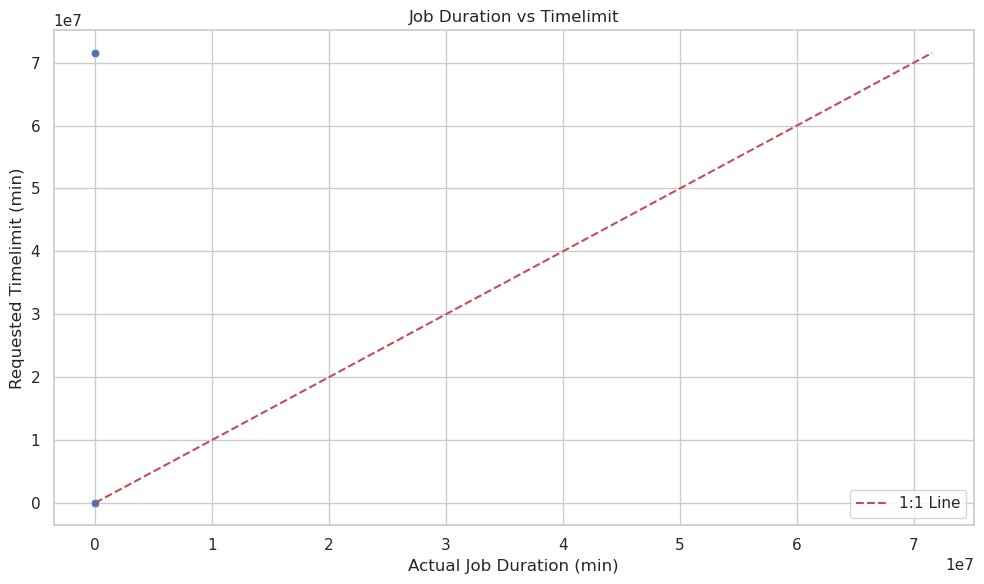

In [11]:
# --- 4. Job Duration vs Timelimit ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=job_agg, x='job_duration_min', y='timelimit_min', alpha=0.7)
plt.plot([0, job_agg['timelimit_min'].max()], [0, job_agg['timelimit_min'].max()], 'r--', label="1:1 Line")
plt.title("Job Duration vs Timelimit")
plt.xlabel("Actual Job Duration (min)")
plt.ylabel("Requested Timelimit (min)")
plt.legend()
plt.tight_layout()
plt.show()

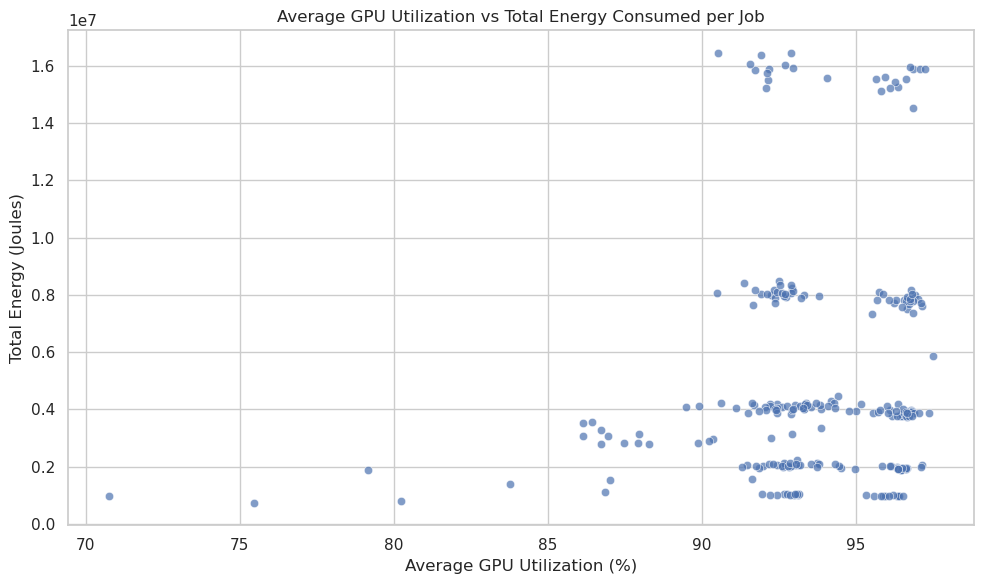

In [12]:
# --- 5. Energy vs Avg Utilization (Efficiency Insight) ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=job_agg, x='avg_utilization', y='total_energy_J', alpha=0.7)
plt.title("Average GPU Utilization vs Total Energy Consumed per Job")
plt.xlabel("Average GPU Utilization (%)")
plt.ylabel("Total Energy (Joules)")
plt.tight_layout()
plt.show()

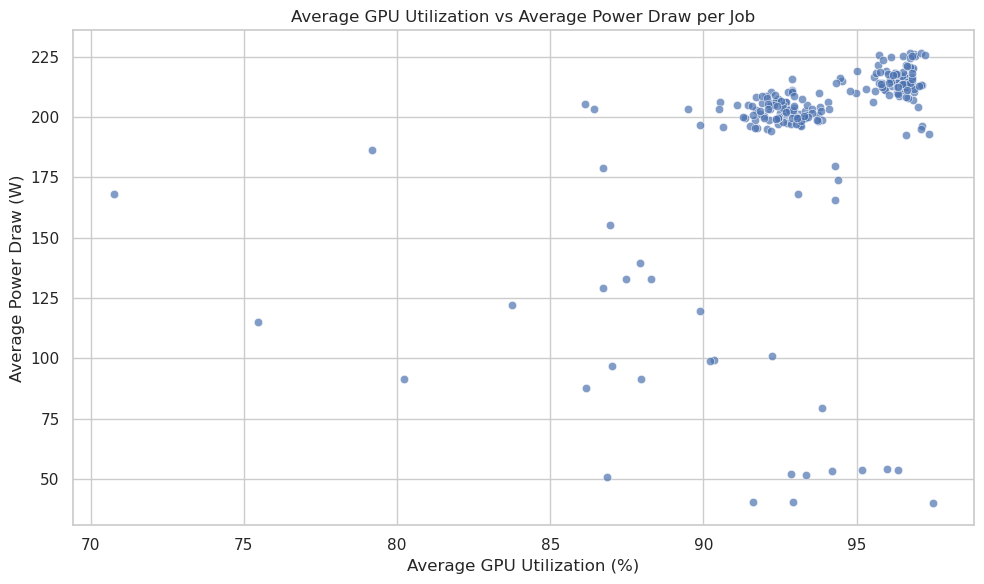

In [13]:
# --- 6. Avg Power vs Utilization (Efficiency Proxy) ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=job_agg, x='avg_utilization', y='avg_power_draw', alpha=0.7)
plt.title("Average GPU Utilization vs Average Power Draw per Job")
plt.xlabel("Average GPU Utilization (%)")
plt.ylabel("Average Power Draw (W)")
plt.tight_layout()
plt.show()

In [ ]:
# --- 7. GPU Utilization over Time (Lineplot for Few Jobs) ---
sample_jobs = df['id_job'].value_counts().head(3).index  # pick 3 largest jobs

for job_id in sample_jobs:
    df_job = df[df['id_job'] == job_id]
    plt.figure(figsize=(12, 5))
    sns.lineplot(data=df_job, x='timestamp', y='utilization_gpu_pct')
    plt.title(f"GPU Utilization Over Time - Job {job_id}")
    plt.xlabel("Timestamp")
    plt.ylabel("GPU Utilization (%)")
    plt.tight_layout()
    plt.show()
